# Notebook 06 — Baseline Evaluation
**Nhóm 67 | Tuần 3 | Ngôn ngữ Lập trình Python**

Notebook này thực hiện đánh giá **Baseline** — chạy code chuẩn (AC) của 50 bài toán để:
1. **Sanity check**: Xác nhận hệ thống chấm bài và bộ test case hoạt động đúng.
2. **Đo latency chuẩn**: Tốc độ chạy của code tối ưu làm điểm neo so sánh.
3. **Phân tích so sánh**: Đặt baseline bên cạnh kết quả bài nộp sinh viên để minh họa FPR.

> **Tối ưu**: Script `run_baseline.py` dùng `ThreadPoolExecutor` chạy 50 bài song song → nhanh hơn ~3-5x so với tuần tự.

## Bước 1 — Thiết lập đường dẫn và import

In [3]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from pathlib import Path

# Detect Colab (Google Drive) vs Local
colab_mode = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    colab_mode = True
except Exception:
    colab_mode = False

# Resolve BASE path dynamically
BASE = next((p for p in [Path.cwd().resolve()] + list(Path.cwd().resolve().parents) if (p / 'data').exists() or (p / 'app.py').exists()), Path.cwd().resolve())
if not colab_mode:
    cwd = Path.cwd()
    if cwd.name in {'notebookes', 'notebooks', 'src', 'data', 'results'}:
        BASE = cwd.parent
    else:
        BASE = cwd

sys.path.insert(0, str(BASE / 'src'))
os.chdir(BASE)

print(f'✓ BASE = {BASE}')
print(f'✓ Dataset: {(BASE / "data" / "processed" / "hidden_v2.json").exists()}')
print(f'✓ runner_v2.py: {(BASE / "src" / "runner_v2.py").exists()}')
print(f'✓ run_baseline.py: {(BASE / "src" / "run_baseline.py").exists()}')


✓ BASE = 
✓ Dataset: True
✓ runner_v2.py: True
✓ run_baseline.py: True


In [ ]:
# ═══════════════════════════════════════════════════════════
# PATCH runner_v3.py trực tiếp trên Google Drive
# Thêm so sánh số nguyên lớn vào hàm _compare()
# ═══════════════════════════════════════════════════════════

runner_path = str(BASE / 'src' / 'runner_v3.py')

# Đọc nội dung hiện tại
with open(runner_path, "r", encoding="utf-8") as f:
    code = f.read()

# Chuỗi CŨ (dòng so sánh số thực) — cần thêm so sánh int TRƯỚC đó
OLD = "    # Thử so sánh số thực đơn giản\n    try:\n        return math.isclose(float(actual_clean), float(expected_clean), rel_tol=1e-9, abs_tol=1e-9)\n    except (ValueError, TypeError):\n        pass"

# Chuỗi MỚI — thêm khối so sánh int TRƯỚC khi so sánh float
NEW = """    # Thử so sánh số nguyên trực tiếp (bao gồm cả số Bell và số cực lớn)
    try:
        return int(actual_clean) == int(expected_clean)
    except (ValueError, TypeError, OverflowError):
        pass

    # Thử so sánh số thực đơn giản
    try:
        return math.isclose(float(actual_clean), float(expected_clean), rel_tol=1e-9, abs_tol=1e-9)
    except (ValueError, TypeError):
        pass"""

if "int(actual_clean) == int(expected_clean)" in code:
    print("✅ Bản vá đã có sẵn trong runner_v3.py — không cần vá lại!")
elif OLD in code:
    code_patched = code.replace(OLD, NEW)
    with open(runner_path, "w", encoding="utf-8") as f:
        f.write(code_patched)
    print("✅ Đã vá runner_v3.py thành công!")
else:
    print("⚠️ Không tìm thấy đoạn cần vá — hãy paste nội dung dưới đây vào ô tiếp theo để kiểm tra thủ công:")
    # In dòng so sánh thực tế đang có trong file
    for i, line in enumerate(code.split('\n')):
        if 'isclose' in line or 'float(actual' in line:
            print(f"  Dòng {i+1}: {line}")

✅ Bản vá đã có sẵn trong runner_v3.py — không cần vá lại!


## Bước 2 — Chạy Baseline (Song song, tối ưu tốc độ)

In [ ]:
import run_baseline

# Chạy baseline và lưu kết quả
run_baseline.main()

  CHẠY BASELINE — Code chuẩn trên 50 bài toán
  Dataset: hidden_v2.json  |  Luồng song song: 8

  ✓ Đã load 100 bài toán
  → Mỗi bài: 3 public + 6 hidden tests

  Bắt đầu chạy song song (8 luồng)...

  [✓] Task  6 factorial                      pub=3/3 hid=6/6 lat=0.4476s
  [✓] Task  7 is_palindrome                  pub=3/3 hid=6/6 lat=0.4822s
  [✓] Task  4 find_max                       pub=3/3 hid=6/6 lat=0.508s
  [✓] Task  5 count_char                     pub=3/3 hid=6/6 lat=0.513s
  [✓] Task  3 reverse_string                 pub=3/3 hid=6/6 lat=0.5114s
  [✓] Task  1 sum_list                       pub=3/3 hid=6/6 lat=0.5069s
  [✓] Task  2 is_even                        pub=3/3 hid=6/6 lat=0.5103s
  [✓] Task  8 remove_duplicates              pub=3/3 hid=6/6 lat=0.5117s
  [✓] Task 10 to_uppercase                   pub=3/3 hid=6/6 lat=0.4141s
  [✓] Task  9 average                        pub=3/3 hid=6/6 lat=0.4489s
  [✓] Task 12 sum_even                       pub=3/3 hid=6/6 lat=0.4075s

## Bước 3 — Load và kiểm tra kết quả

In [ ]:
# Load kết quả baseline
df_bl = pd.read_csv(BASE / 'results' / 'baseline_summary.csv')

print(f'Số bài toán: {len(df_bl)}')
print(f'Baseline OK (pass 100%): {df_bl["baseline_ok"].sum()}/{len(df_bl)}')
print(f'\nLatency public trung bình : {df_bl["pub_latency"].mean():.4f}s/test')
print(f'Latency hidden trung bình  : {df_bl["hid_latency"].mean():.4f}s/test')
print(f'Latency tổng trung bình    : {df_bl["avg_latency_total"].mean():.4f}s/test')
print()

# Hiển thị bảng
display(df_bl[['task_id', 'func_name', 'topic', 'pub_pass', 'pub_total', 'hid_pass', 'hid_total', 'baseline_ok', 'avg_latency_total']].head(10))

Số bài toán: 100
Baseline OK (pass 100%): 100/100

Latency public trung bình : 0.4193s/test
Latency hidden trung bình  : 0.4223s/test
Latency tổng trung bình    : 0.4208s/test



,task_id,func_name,topic,pub_pass,pub_total,hid_pass,hid_total,baseline_ok,avg_latency_total
0,1,sum_list,list,3,3,6,6,True,0.3659
1,2,is_even,math,3,3,6,6,True,0.4036
2,3,reverse_string,string,3,3,6,6,True,0.3754
3,4,find_max,list,3,3,6,6,True,0.4109
4,5,count_char,string,3,3,6,6,True,0.4055
5,6,factorial,math,3,3,6,6,True,0.3744
6,7,is_palindrome,string,3,3,6,6,True,0.3832
7,8,remove_duplicates,list,3,3,6,6,True,0.3670
8,9,average,math,3,3,6,6,True,0.5441
9,10,to_uppercase,string,3,3,6,6,True,0.5140


## Bước 4 — Kiểm tra bài nào FAIL (nếu có)

In [ ]:
# Tìm bài bị fail
df_fail = df_bl[df_bl['baseline_ok'] == False]

if len(df_fail) == 0:
    print('✅ Tất cả 100 bài đều PASS — Bộ test case hợp lệ hoàn toàn!')
else:
    print(f'⚠️ Có {len(df_fail)} bài FAIL — Cần kiểm tra test case!')
    display(df_fail[['task_id', 'func_name', 'topic', 'pub_tpr', 'hid_tpr', 'pub_WA', 'hid_WA', 'pub_RE', 'hid_RE']])

✅ Tất cả 100 bài đều PASS — Bộ test case hợp lệ hoàn toàn!


## Bước 5 — Phân tích Latency theo Topic

In [ ]:
# Phân tích latency theo chủ đề
lat_by_topic = df_bl.groupby('topic')['avg_latency_total'].agg(['mean', 'min', 'max', 'std']).round(4)
lat_by_topic.columns = ['Trung bình (s)', 'Min (s)', 'Max (s)', 'Std (s)']
print('Latency theo chủ đề bài toán:')
display(lat_by_topic)

Latency theo chủ đề bài toán:


,Trung bình (s),Min (s),Max (s),Std (s)
topic,,,,
list,0.4244,0.2704,0.6123,0.0897
math,0.4469,0.2867,0.7110,0.0978
string,0.3858,0.2950,0.5140,0.0551


## Bước 6 — Biểu đồ Latency Baseline vs Bài nộp sinh viên

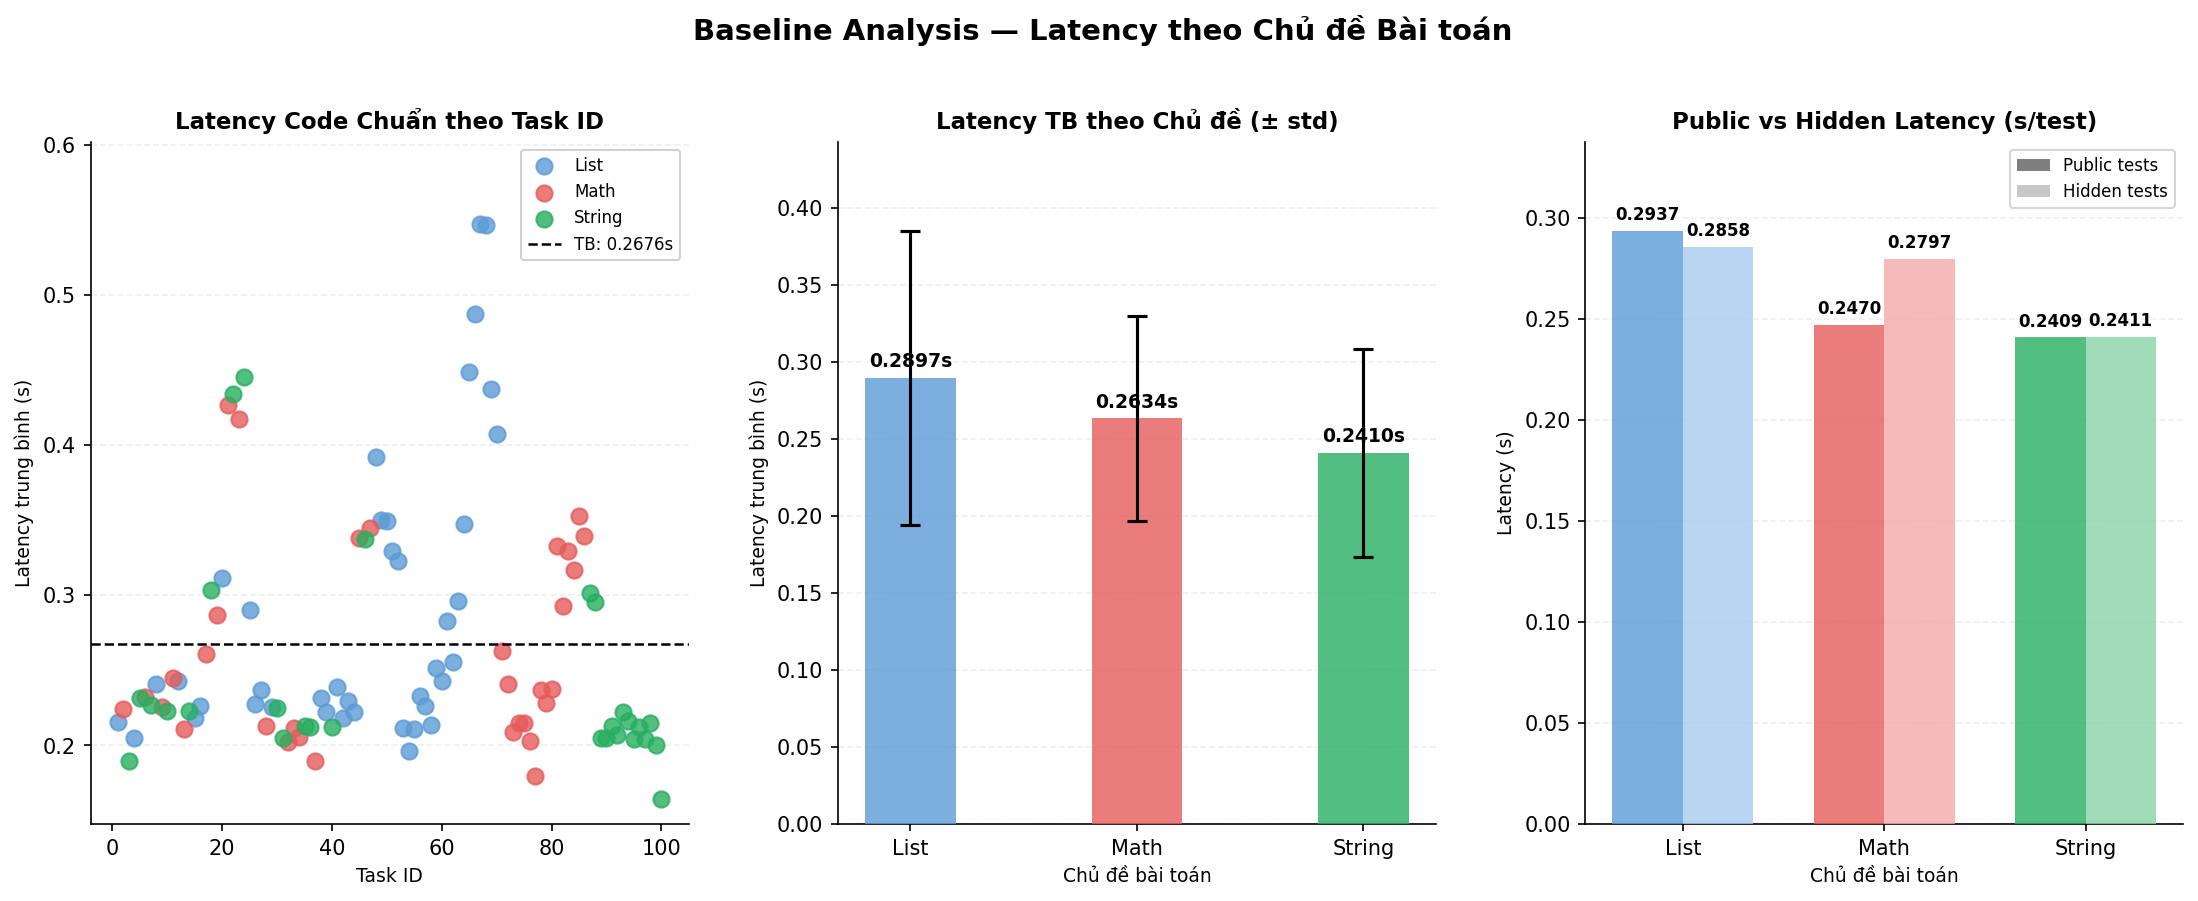

In [4]:
# Load kết quả baseline
df_bl = pd.read_csv(BASE / 'results' / 'baseline_summary.csv')

# Create the figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), dpi=150)
fig.suptitle('Baseline Analysis — Latency theo Chủ đề Bài toán', fontsize=14, fontweight='bold', y=0.98)

# Colors matching user image
colors = {'list': '#5B9BD5', 'math': '#E55B5B', 'string': '#27AE60'}
light_colors = {'list': '#A9CBEF', 'math': '#F5A9A9', 'string': '#8AD4A6'}

# ── Subplot 1: Latency Code Chuẩn theo Task ID ──
ax1 = axes[0]
for topic, grp in df_bl.groupby('topic'):
    ax1.scatter(grp['task_id'], grp['avg_latency_total'],
                label=topic.capitalize(), color=colors.get(topic, '#888'),
                s=60, alpha=0.8, zorder=3)

avg_lat = df_bl['avg_latency_total'].mean()
ax1.axhline(avg_lat, color='black', linestyle='--', linewidth=1.2,
            label=f'TB: {avg_lat:.4f}s', zorder=4)
ax1.set_title('Latency Code Chuẩn theo Task ID', fontsize=11, fontweight='bold')
ax1.set_xlabel('Task ID', fontsize=9)
ax1.set_ylabel('Latency trung bình (s)', fontsize=9)
ax1.legend(fontsize=8, framealpha=0.9, loc='upper right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.2, linestyle='--')

# TỰ ĐỘNG HÓA TRỤC 1: Dựa theo min/max thực tế của dữ liệu
y_min = df_bl['avg_latency_total'].min() * 0.9
ax1.set_ylim(y_min, df_bl['avg_latency_total'].max() * 1.1)

# ── Subplot 2: Latency TB theo Chủ đề (± std) ──
ax2 = axes[1]
topics = ['list', 'math', 'string']
means = [df_bl[df_bl['topic'] == t]['avg_latency_total'].mean() for t in topics]
stds = [df_bl[df_bl['topic'] == t]['avg_latency_total'].std() for t in topics]

bars = ax2.bar(topics, means, yerr=stds, capsize=5,
               color=[colors[t] for t in topics], alpha=0.8,
               error_kw={'ecolor': 'black', 'elinewidth': 1.5, 'capthick': 1.5},
               width=0.4, zorder=3)

# TỰ ĐỘNG HÓA TRỤC 2: Tính toán giới hạn y cực đại dựa trên mean + std
y_max_ax2 = max([m + s for m, s in zip(means, stds)]) * 1.15

# Add text labels on top of the bars
for bar, m in zip(bars, means):
    h = bar.get_height()
    # Nhãn chữ sẽ cách đỉnh cột một khoảng bằng 1% giới hạn trục dọc cực đại
    ax2.text(bar.get_x() + bar.get_width()/2.0, h + y_max_ax2 * 0.01,
             f'{m:.4f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Latency TB theo Chủ đề (± std)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Chủ đề bài toán', fontsize=9)
ax2.set_ylabel('Latency trung bình (s)', fontsize=9)
ax2.set_xticks(np.arange(len(topics)))
ax2.set_xticklabels(['List', 'Math', 'String'])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.2, linestyle='--')
ax2.set_ylim(0.0, y_max_ax2)

# ── Subplot 3: Public vs Hidden Latency (s/test) ──
ax3 = axes[2]
w = 0.35
x_indices = np.arange(len(topics))

pub_means = [df_bl[df_bl['topic'] == t]['pub_latency'].mean() for t in topics]
hid_means = [df_bl[df_bl['topic'] == t]['hid_latency'].mean() for t in topics]

# Grouped bar chart
bars_pub = ax3.bar(x_indices - w/2, pub_means, w,
                   color=[colors[t] for t in topics], alpha=0.8, zorder=3)
bars_hid = ax3.bar(x_indices + w/2, hid_means, w,
                   color=[light_colors[t] for t in topics], alpha=0.8, zorder=3)

# TỰ ĐỘNG HÓA TRỤC 3: Tính toán giới hạn y cực đại dựa trên public/hidden latency lớn nhất
y_max_ax3 = max(max(pub_means), max(hid_means)) * 1.15

# Add text labels on top of the bars
for bar, val in zip(bars_pub, pub_means):
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2.0, h + y_max_ax3 * 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for bar, val in zip(bars_hid, hid_means):
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2.0, h + y_max_ax3 * 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax3.set_title('Public vs Hidden Latency (s/test)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Chủ đề bài toán', fontsize=9)
ax3.set_ylabel('Latency (s)', fontsize=9)
ax3.set_xticks(x_indices)
ax3.set_xticklabels(['List', 'Math', 'String'])

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#7F7F7F', label='Public tests'),
    Patch(facecolor='#C7C7C7', label='Hidden tests')
]
ax3.legend(handles=legend_elements, fontsize=8, loc='upper right')

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.2, linestyle='--')
ax3.set_ylim(0.0, y_max_ax3)

out_path = BASE / 'results' / 'baseline_latency.png'
plt.subplots_adjust(top=0.85, bottom=0.15, wspace=0.25)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.subplots_adjust(top=0.85, bottom=0.15, wspace=0.25)
plt.show()

## Bước 7 — Bảng tổng hợp Baseline vs Bài nộp sinh viên (FPR)

In [ ]:
# Auto-load df_bl neu chua chay Buoc 3
if 'df_bl' not in dir() or df_bl is None:
    _bl_csv = BASE / 'results' / 'baseline_summary.csv'
    if _bl_csv.exists():
        df_bl = pd.read_csv(_bl_csv)
    else:
        print('Chua co baseline_summary.csv — Hay chay Buoc 2 truoc')
        df_bl = None

# Load comparison_3sets.json de lay FPR
comp_json = BASE / 'results' / 'comparison_week4.json'
if comp_json.exists() and df_bl is not None:
    with open(comp_json, encoding='utf-8') as f:
        comp = json.load(f)
    stats = comp.get('stats', {})

    rows = []
    for key, label in [('set1', 'Set1_3pub'), ('set2', 'Set2_3P6H'), ('set3', 'Set3_3P10H')]:
        s = stats.get(key, {})
        rows.append({
            'Bo_test'   : label,
            'FP_count'  : s.get('fp_count', '-'),
            'FPR_pct'   : s.get('fpr_pct', '-'),
            'Avg_TPR'   : s.get('avg_tpr', '-'),
            'Latency_s' : s.get('avg_latency', '-'),
        })

    rows.insert(0, {
        'Bo_test'   : 'Baseline_AC',
        'FP_count'  : 0,
        'FPR_pct'   : 0.0,
        'Avg_TPR'   : 100.0,
        'Latency_s' : round(df_bl['avg_latency_total'].mean(), 4),
    })

    df_compare = pd.DataFrame(rows).set_index('Bo_test')

    # Format thu cong, khong can jinja2
    df_fmt = df_compare.copy()
    df_fmt['FPR_pct']   = df_fmt['FPR_pct'].apply(lambda x: f'{x:.1f}%' if isinstance(x, (int, float)) else x)
    df_fmt['Avg_TPR']   = df_fmt['Avg_TPR'].apply(lambda x: f'{x:.1f}%' if isinstance(x, (int, float)) else x)
    df_fmt['Latency_s'] = df_fmt['Latency_s'].apply(lambda x: f'{x:.4f}s' if isinstance(x, (int, float)) else x)

    print('So sanh Baseline vs Bai nop sinh vien theo 3 bo test:')
    display(df_fmt)
elif df_bl is None:
    print('Khong co du lieu baseline — vui long chay Buoc 2 truoc')
else:
    print('Chua co comparison_3sets.json — Chay comparison_3sets.py truoc')


So sanh Baseline vs Bai nop sinh vien theo 3 bo test:


,FP_count,FPR_pct,Avg_TPR,Latency_s
Bo_test,,,,
Baseline_AC,0,0.0%,100.0%,0.4208s
Set1_3pub,17,18.9%,36.3%,-
Set2_3P6H,2,2.2%,39.6%,-
Set3_3P10H,0,0.0%,39.0%,-


## Bước 8 — Kết luận

Bảng tổng hợp dưới đây so sánh:
- **Baseline**: code đúng hoàn toàn → FPR = 0%, TPR = 100%
- **Set 1** (3 public): FPR cao, dễ bị hardcode qua mặt
- **Set 2** (9 tests): FPR giảm đáng kể nhờ hidden tests  
- **Set 3** (13 tests): FPR xuống tối thiểu → độ tin cậy cao nhất

→ **Kết luận RQ1**: Tăng số lượng hidden tests giúp giảm FPR và phát hiện bài nộp gian lận chính xác hơn.